# Dataset Distributions

This notebook investigates the distributions of key political identity-building categories related to political actors, based on dataset metadata - with a focus on sentiment-related trends of membership and group relation categories.  

### Categories of Interest
- **Membership**: Political parties, parliamentary groups, ministers  
- *Ideology*: Party families, GAL–TAN positionings (CHES variables)  
- **Group Relations**: Party status (Coalition vs. Opposition), political orientation (LREGEN, LRECON, Wikipedia classifications)  

### Purpose

The goal of this exploration is to:
1. *Investigate basic distributions* to gain an overview of the dataset’s structure  
2. *Identify trends* within the political landscape of the studied parliamentary period  

### Focus Areas
- *Party activity*: How political parties and groups are distributed and represented  
- *Sentiment trends*: Patterns in sentiment across different ideological or group categories  

--- 

Sample input: 
Pre-processed dataset [ParlaMint-SI_5.1_master.tsv](../Sample/Datasets/ParlaMint-SI_5.1_master.tsv) 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


In [2]:
df = pd.read_csv("../Sample/Datasets/ParlaMint-SI_5.1_master.tsv", sep="\t", encoding="utf-8")

In [3]:
# Families the parties belong to, based of the Family.tsv, acquired through CHES data.
family = {
    "DeSUS":"No family",
    "LDS":"Liberal", 
    "LMŠ":"Liberal", 
    "NSi":"Christian-Democratic", 
    "PS":"Socialist", 
    "SAB + ZaSLD":"No family", 
    "SD + ZLSD":"Socialist", 
    "SDS":"Conservatives", 
    "SLS+SKD/SLS":"Christian-Democratic", 
    "SMC/GAS/Konkretno":"Liberal", 
    "SMS":"No family", 
    "SNS":"Radical Right", 
    "ZL/Levica":"Socialist", 
    "ZLSD/SD":"Socialist", 
    "ZaAB/ZaSLD/SAB":"No family", 
    "Zares":"Liberal"

}

# Groups of political parties, as per <listEvent> 
groups = {
    "ZL": "ZL/Levica",
    "Levica": "ZL/Levica",
    "ZaAB":"ZaAB/ZaSLD/SAB",
    "ZaSLD":"ZaAB/ZaSLD/SAB",
    "SAB" :"ZaAB/ZaSLD/SAB",
    "ZLSD":"ZLSD/SD",
    "SD":"ZLSD/SD",
    "SLS+SKD":"SLS+SKD/SLS",
    "SLS":"SLS+SKD/SLS", 
    "DLGV":"DLGV/DL", 
    "DL":"DLGV/DL",
    "SMC":"SMC/GAS/Konkretno",
    "Konkretno": "SMC/GAS/Konkretno"
}

df["Grouped_parties"] = df['Speaker_party'].replace(groups).fillna(df['Speaker_party'])
df["Family"] = df['Grouped_parties'].map(family).fillna("No family")

df[["Grouped_parties", "Family"]].value_counts()

Grouped_parties    Family              
SDS                Conservatives           847
ZLSD/SD            Socialist               476
DeSUS              No family               376
LDS                Liberal                 337
SNS                Radical Right           235
-                  No family               228
PS                 Socialist               186
DLGV/DL            No family               161
NSi                Christian-Democratic    134
NP                 No family               134
LMŠ                Liberal                 130
ZL/Levica          Socialist               101
SLS+SKD/SLS        Christian-Democratic     78
ZaAB/ZaSLD/SAB     No family                51
NeP                No family                27
SMC/GAS/Konkretno  Liberal                  14
IMNS               No family                14
SMS                No family                 5
Name: count, dtype: int64

In [4]:
df.head()
df.to_csv("../Results/Datasets/ParlaMint-SI_Family.tsv", sep="\t", encoding="utf-8", index=False)

## Dataset characteristics

In [5]:
print(df.shape)
df.describe(include="all")

(3534, 26)


,ID,Text,Date,Term,Meeting,Subcorpus,Speaker_role,Speaker_MP,Speaker_minister,Speaker_party,...,Speaker_birth,Topic,Senti_3,Senti_6,Senti_n,Sents,Words,Tokens,Grouped_parties,Family
count,3534,3534,3534,3534,3534,3534,3534,3534,3534,3534,...,3534,3534,3534,3534,3534.000000,3534.000000,3534.000000,3534.000000,3534,3534
unique,3534,3413,20,4,2,2,2,2,2,20,...,53,23,3,6,NaN,NaN,NaN,NaN,18,6
top,ParlaMint-SI_2014-01-27-SDZ6-Redna-21.u1,"Hvala lepa. Izvolite, gospod minister.",2022-01-31,6. mandat,Redna,Reference,Chairperson,MP,notMinister,SDS,...,1960,Other,Neutral,neutral positive,NaN,NaN,NaN,NaN,SDS,No family
freq,1,15,405,1231,2919,2518,1786,3287,3340,847,...,337,1730,2143,1763,NaN,NaN,NaN,NaN,847,996
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.077479,12.547821,228.014431,265.902377,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.315301,19.549797,401.653471,467.748263,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000000,1.000000,1.000000,1.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.600000,3.000000,12.000000,15.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.840000,6.000000,73.000000,87.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3.000000,17.000000,327.750000,377.000000,NaN,NaN


In [6]:
reg_speeches = df[df["Speaker_role"] == "Regular"]
party = df["Speaker_party"].unique()

print("No. of all speeches: ", len(df))
print("Speeches of regular speakers: ", len(reg_speeches), "%: ", (len(reg_speeches)/len(df))*100)
print("Earliest date: ", df["Date"].min())
print("Latest date: ", df["Date"].max())
print("No. of unique parties ", len(party), party)
print("Sentiment 6-class: ", df["Senti_6"].value_counts())
print("Sentiment 3-class: ", df["Senti_3"].value_counts()
)

No. of all speeches:  3534
Speeches of regular speakers:  1748 %:  49.46236559139785
Earliest date:  2000-10-27
Latest date:  2022-02-02
No. of unique parties  20 ['SD' 'SDS' '-' 'SLS' 'NSi' 'DeSUS' 'PS' 'DL' 'NeP' 'IMNS' 'NP' 'Levica'
 'LMŠ' 'SAB' 'SNS' 'Konkretno' 'LDS' 'SLS+SKD' 'ZLSD' 'SMS']
Sentiment 6-class:  Senti_6
neutral positive    1763
negative             818
neutral negative     380
mixed negative       355
mixed positive       172
positive              46
Name: count, dtype: int64
Sentiment 3-class:  Senti_3
Neutral     2143
Negative    1173
Positive     218
Name: count, dtype: int64


In [7]:
# Removing procedural speeches for the analysis, rechecking base characteristics
df = df[df["Speaker_role"] == "Regular"]

print("No. of all speeches: ", len(df))
print("Earliest date: ", df["Date"].min())
print("Latest date: ", df["Date"].max())
print("No. of unique parties ", len(party), party)
print("Sentiment 6-class: ", df["Senti_6"].value_counts())
print("Sentiment 3-class: ", df["Senti_3"].value_counts())


No. of all speeches:  1748
Earliest date:  2000-10-27
Latest date:  2022-02-02
No. of unique parties  20 ['SD' 'SDS' '-' 'SLS' 'NSi' 'DeSUS' 'PS' 'DL' 'NeP' 'IMNS' 'NP' 'Levica'
 'LMŠ' 'SAB' 'SNS' 'Konkretno' 'LDS' 'SLS+SKD' 'ZLSD' 'SMS']
Sentiment 6-class:  Senti_6
negative            798
mixed negative      294
neutral negative    236
neutral positive    218
mixed positive      158
positive             44
Name: count, dtype: int64
Sentiment 3-class:  Senti_3
Negative    1092
Neutral      454
Positive     202
Name: count, dtype: int64


## Party-level Overview
Inspecting speech and sentiment distributions across party-, status- and political orientation.

In [8]:
# Table with overview of speeches, sentiment avg and sent percentages
#mapping = {"Far right":"FR", 
# "Right to far right": "R-FR", 
# "Centre-right":"CR", 
# "Centre to centre-left":"C-CR", 
# "Centre":"C", 
# "Centre to centre-left":"C-CL", 
# "Centre-left":"CL", 
# "Left":"L", 
# "Left to far left": "L-FL", 
# "Far left": "FL", 
# "-":"-", }

status = df.groupby(['Speaker_party','Party_status']).size().unstack(fill_value=0)
status.columns = ['Speech (U)', 'Speech (C)', 'Speech (O)']
avg_sent = df.groupby(['Speaker_party', 'Party_status'])["Senti_n"].mean().unstack(fill_value=0)
avg_sent.columns = ['Avg. Sent (U)', 'Avg. Sent (C)', 'Avg. Sent (O)']
sent_count = df.groupby(['Speaker_party', df['Senti_3']]).size().unstack(fill_value=0)
sent_percent = sent_count.div(sent_count.sum(axis=1), axis=0) * 100

party_metadata = df[['Speaker_party', 'Party_orientation']].drop_duplicates().set_index('Speaker_party')


overview = (
    status.merge(avg_sent, on="Speaker_party", how="left")
    .merge(sent_percent, on="Speaker_party", how="left")
    .merge(party_metadata, on="Speaker_party", how='left')
    .reset_index()
    )

overview.rename(columns={
    'Positive': '% Positive',
    'Neutral': '% Neutral',
    'Negative': '% Negative'
}, inplace=True)


overview['Total Speeches'] = overview['Speech (U)'] + overview['Speech (C)'] + overview['Speech (O)']
total_speeches = overview['Total Speeches'].sum()
overview['Speech %'] = (overview['Total Speeches'] / total_speeches) * 100
overview = overview[['Speaker_party', 'Party_orientation', 'Total Speeches', 'Speech %', 'Speech (C)', 'Speech (O)','Speech (U)',
               'Avg. Sent (C)', 'Avg. Sent (O)','Avg. Sent (U)', '% Positive', '% Neutral', '% Negative']]

cols_to_format = [
    'Speech %', 'Avg. Sent (C)', 'Avg. Sent (O)', 'Avg. Sent (U)',
    '% Positive', '% Neutral', '% Negative'
]

for col in cols_to_format:
    overview[col] = overview[col].map(lambda x: f"{x:.1f}")

overview

,Speaker_party,Party_orientation,Total Speeches,Speech %,Speech (C),Speech (O),Speech (U),Avg. Sent (C),Avg. Sent (O),Avg. Sent (U),% Positive,% Neutral,% Negative
0,-,-,228,13.0,0,0,228,0.0,0.0,2.4,27.6,46.5,25.9
1,DL,Centre to centre-right,42,2.4,42,0,0,1.8,0.0,0.0,19.0,26.2,54.8
2,DeSUS,Centre to centre-left,84,4.8,84,0,0,1.7,0.0,0.0,15.5,31.0,53.6
3,IMNS,-,14,0.8,0,0,14,0.0,0.0,2.5,35.7,35.7,28.6
4,Konkretno,Centre,14,0.8,14,0,0,2.6,0.0,0.0,42.9,28.6,28.6
5,LDS,Centre to centre-left,162,9.3,30,132,0,2.9,0.6,0.0,5.6,22.8,71.6
6,LMŠ,Centre to centre-left,55,3.1,0,55,0,0.0,1.0,0.0,5.5,18.2,76.4
7,Levica,Left,101,5.8,0,101,0,0.0,0.3,0.0,0.0,5.9,94.1
8,NP,-,14,0.8,0,0,14,0.0,0.0,0.6,7.1,7.1,85.7
9,NSi,Centre-right,114,6.5,80,34,0,1.8,1.1,0.0,19.3,25.4,55.3


## Party Activity
Investigation of party presence throughout the period, covered by the dataset. There are also several exceptions that need to be handled: 
- NeP = parliamentary group of independent MPs, which could be considered for the analysis, however, since there is no destinction between different NePs in different mandates, this is not included in the visualisation.
- NP = individual independent MPs, not connected into a parliamentary group. In addition to them not being a formal parliamentary entity but individual speakers, they have similar problem as NeP, ruled out
- Lipa and Konkretno = both are non-parliamentary parties. Specfically, both parties were consistuted within Parliament after being elected as a different parliamentary party. Included in the analysis

In [9]:
# Renaming slv metadata to eng (X. mandat -> Term X)
df['Term'] = df['Term'].replace({
    '3. mandat': 'Term 3',
    '4. mandat': 'Term 4',
    '5. mandat': 'Term 5',
    '6. mandat': 'Term 6',
    '7. mandat': 'Term 7',
    '8. mandat': 'Term 8'
})
df['Year'] = df['Date'].str.split('-').str[0]

activity = df.groupby(['Term', 'Speaker_party']).agg(
    Start_date=('Date', 'min'),
    End_date=('Date', 'max'),
    Speech_count=('Date', 'size')
).reset_index()
activity = activity[~activity['Speaker_party'].isin(["-", "NeP", "NP"])]

activity["Grouped_parties"] = activity['Speaker_party'].replace(groups).fillna(activity['Speaker_party'])
activity.head()

,Term,Speaker_party,Start_date,End_date,Speech_count,Grouped_parties
1,Term 3,DeSUS,2000-10-27,2000-11-16,3,DeSUS
2,Term 3,IMNS,2000-11-16,2000-11-17,2,IMNS
3,Term 3,LDS,2000-10-27,2000-11-21,30,LDS
4,Term 3,NSi,2000-10-27,2000-10-27,3,NSi
5,Term 3,SDS,2000-11-10,2000-11-10,1,SDS


In [10]:
import plotly.express as px
from PIL import Image

def plot_party_activity(df, mode="timeline"):
    if mode=="scatter":  ## Use for sample visualisation, for full dataset, use timeline
        fig = px.scatter(
            activity, 
            x="Start_date", 
            y="Grouped_parties", #Can be either Speaker_party for full range of individual parties, or Grouped_parties to emphasise changes in the lifespan of parties 
            size="Speech_count", 
            color="Grouped_parties", 
            hover_name="Grouped_parties", 
            title="Party activity", 
            labels={"Speech_count": "Speech Count"},
        )
    elif mode=="timeline":
        fig = px.timeline(
            activity,
            x_start="Start_date",
            x_end="End_date",
            y="Speaker_party",
            color="Speech_count",
            title="Party Activity Across Terms (Gantt Chart)",
            labels={"Speech_count": "Party Activity"},
        )
    else:
        raise ValueError("mode must be one of: scatter, bar, heatmap, timeline")
    fig.update_layout(yaxis_title="Party", xaxis_title="")
    return fig

#fig.write_image("path.png")

fig = plot_party_activity(activity, mode="scatter")
fig.show()

## Sentiment trends (across party, political orientations, statuses...)

In [11]:
sent_mapping = {
    "negative":"Negative", 
    "neutral negative":"Neutral Negative", 
    "neutral positive":"Neutral Positive", 
    "mixed negative":"Mixed Negative", 
    "mixed positive":"Mixed Positive", 
    "positive":"Positive",
}

df['Senti_6'] = df["Senti_6"].map(sent_mapping).fillna(df["Senti_6"])
df["Senti_6"].unique()

array(['Negative', 'Mixed Negative', 'Mixed Positive', 'Neutral Positive',
       'Neutral Negative', 'Positive'], dtype=object)

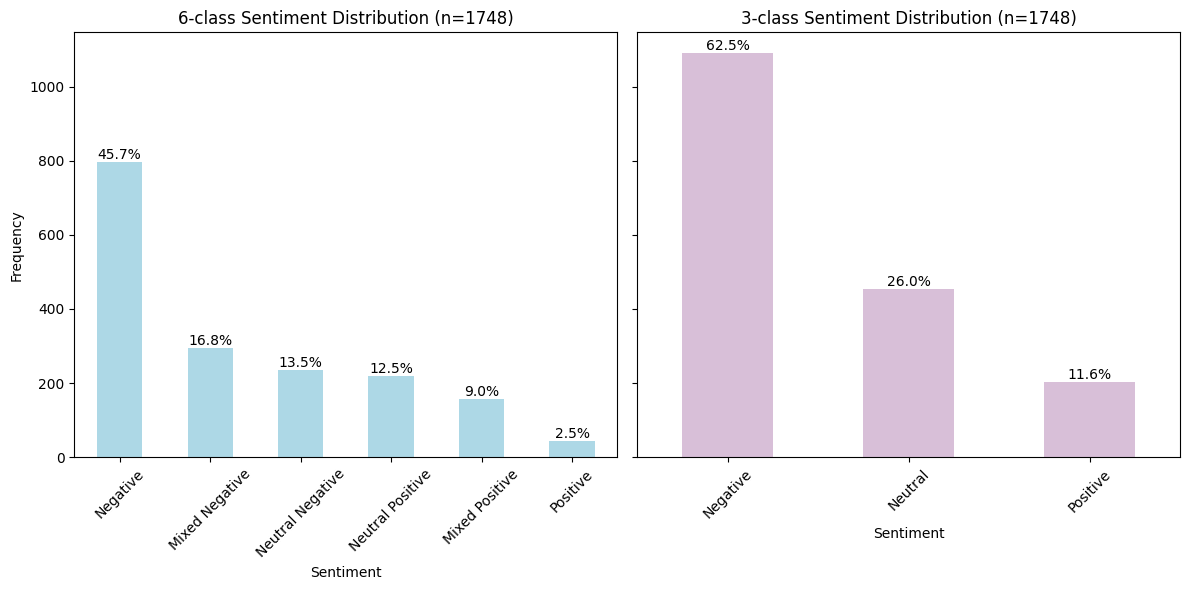

In [12]:
#General sentiment distribution in the corpus
df_sent6 = df["Senti_6"].value_counts()
df_sent3 = df["Senti_3"].value_counts()

def add_percentage(ax, counts):
    total = counts.sum()
    for p in ax.patches:
        percentage = f"{(p.get_height() / total) * 100:.1f}%"
        ax.annotate(percentage,  (p.get_x() + p.get_width() / 2, p.get_height()), 
                    ha='center', va='bottom', fontsize=10, color='black')

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
df_sent6.plot(kind='bar', ax=axes[0], color = 'lightblue')
axes[0].set_title(f'6-class Sentiment Distribution (n={len(df)})')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=45)
add_percentage(axes[0], df_sent6)

df_sent3.plot(kind='bar', ax=axes[1], color='thistle')
axes[1].set_title(f'3-class Sentiment Distribution (n={len(df)})')
axes[1].set_xlabel('Sentiment')
axes[1].tick_params(axis='x', rotation=45)
add_percentage(axes[1], df_sent3)

plt.tight_layout()
plt.show()

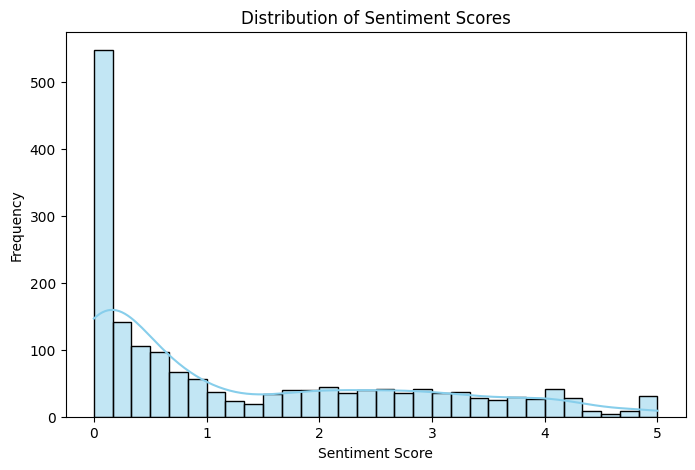

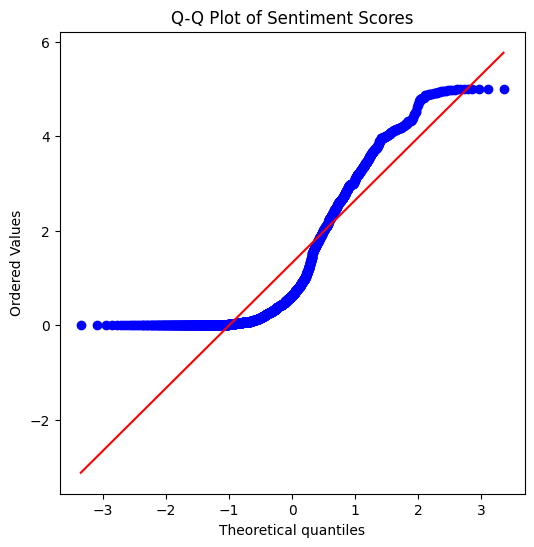

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Senti_n"], bins=30, kde=True, color="skyblue", edgecolor="black")
plt.title("Distribution of Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6, 6))
stats.probplot(df["Senti_n"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Sentiment Scores")
plt.show()

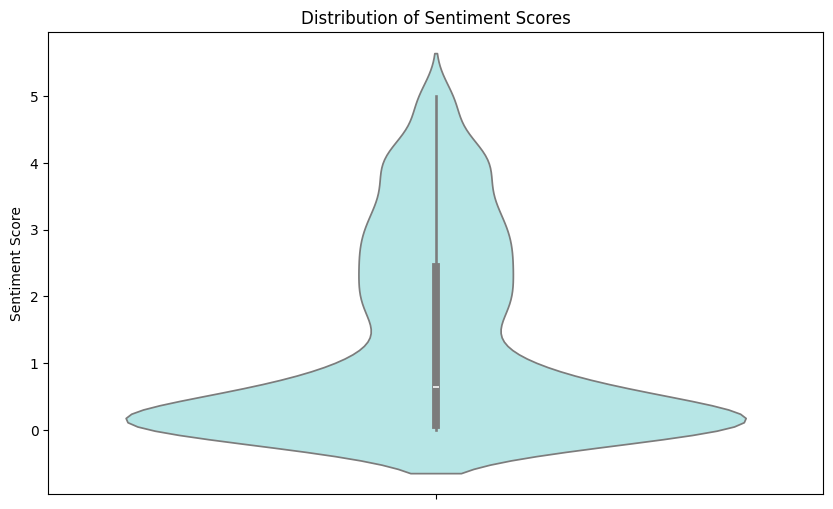

In [14]:
#Sentiment scores distribution
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    y="Senti_n", 
    color="paleturquoise",
)
plt.title("Distribution of Sentiment Scores")
plt.ylabel("Sentiment Score")
plt.show()


### Party status x Sentiment (categories, numerical scores)

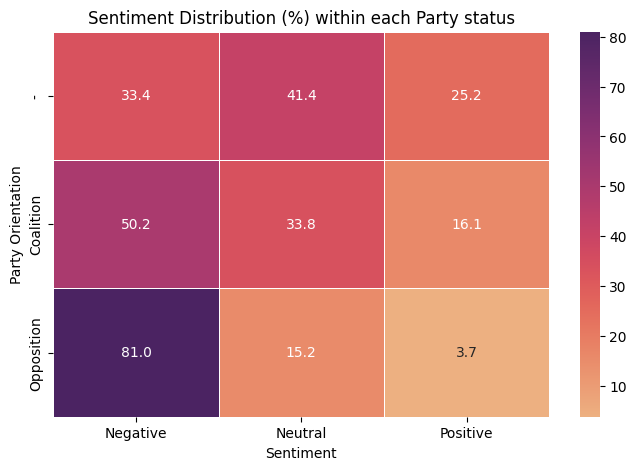

In [15]:
# Party status x Sentiment categories 
# Choose normalization mode: "row", "col", "global", or "none"

mode = "row"
senti_version = 3

if senti_version == 3:
    crosstab = pd.crosstab(df['Party_status'], df['Senti_3'])
elif senti_version == 6:
    crosstab = pd.crosstab(df['Party_status'], df['Senti_6'])
else:
    raise ValueError("Senti_version must be either 3 or 6")

if mode == "row":
    # Each row sums to 100%
    data = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
    fmt = ".1f"
    title = "Sentiment Distribution (%) within each Party status"

elif mode == "col":
    # Each column sums to 100%
    data = crosstab.div(crosstab.sum(axis=0), axis=1) * 100
    fmt = ".1f"
    title = "Status Contributions (%) within each Sentiment"

elif mode == "global":
    # Whole table sums to 100%
    data = crosstab / crosstab.values.sum() * 100
    fmt = ".2f"
    title = "Overall Share of Dataset (%)"

else:  # raw counts
    data = crosstab
    fmt = "g"
    title = "Raw Sentiment Counts by Party Status"


plt.figure(figsize=(8, 5))
sns.heatmap(data, cmap="flare", annot=True, linewidth=.5, fmt=fmt)
plt.title(title)
plt.ylabel("Party Orientation")
plt.xlabel("Sentiment")
plt.show()



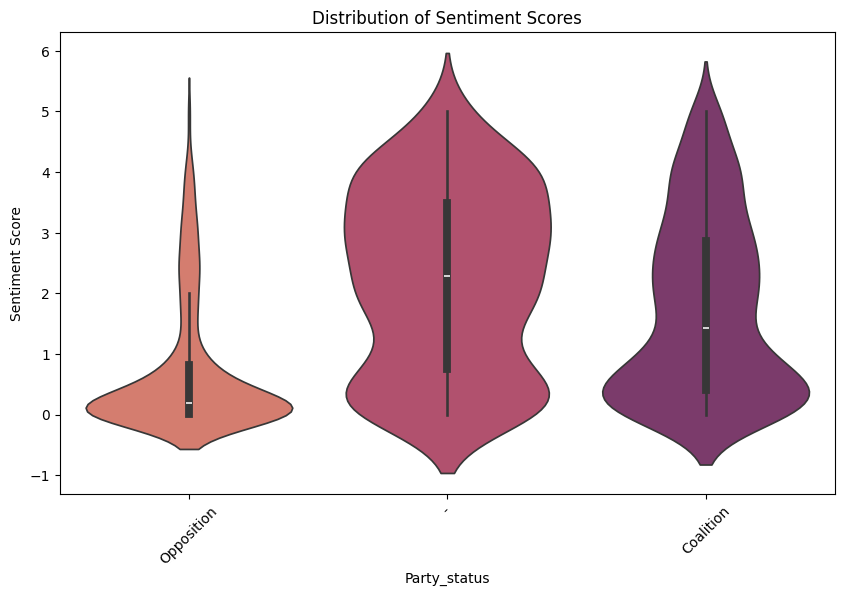

In [16]:
#Party status x sentiment score distribution

plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    x="Party_status",
    y="Senti_n", 
    hue="Party_status",
    palette="flare",
)
plt.title("Distribution of Sentiment Scores")
plt.ylabel("Sentiment Score")
plt.xlabel("Party_status")
plt.xticks(rotation=45)
plt.show()

In [17]:
#Party status x average sentiment score (across years)

status_term = df.groupby(["Party_status", "Year"]).agg({"Senti_n":"mean"}).reset_index()
status_term

fig=px.line(status_term, x="Year", y="Senti_n", color="Party_status", markers=True, 
            color_discrete_sequence=px.colors.qualitative.Vivid)
fig.update_layout(
    height=500,  
    width=950,
    yaxis=dict(range=[0, 5]),

    yaxis_title='Avg. Sentiment score',
    legend_title='Party',
    template='plotly_white'
)
fig.show()

### Political orientation x Sentiment (categories, scores)

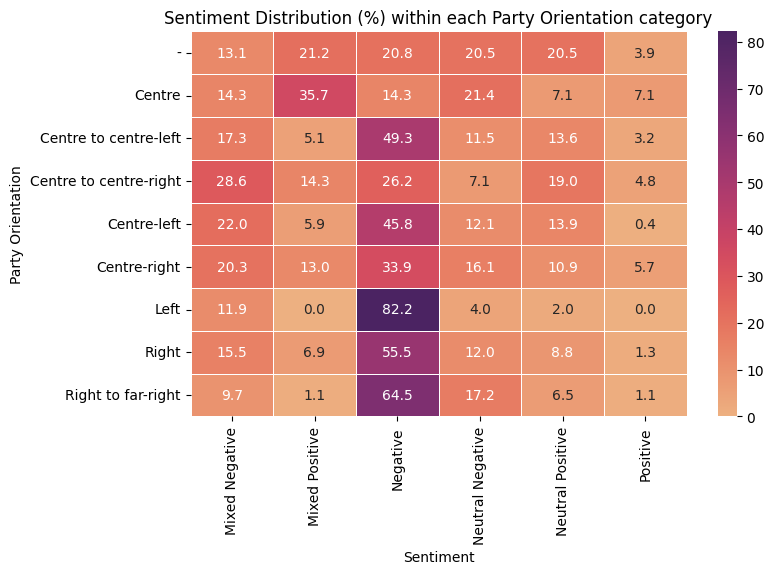

In [18]:
# Political orientation x Sentiment categories 
mode = "row"
senti_version = 6

if senti_version == 3:
    crosstab = pd.crosstab(df['Party_orientation'], df['Senti_3'])
elif senti_version == 6:
    crosstab = pd.crosstab(df['Party_orientation'], df['Senti_6'])
else:
    raise ValueError("Senti_version must be either 3 or 6")

if mode == "row":
    # Each row sums to 100%
    data = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
    fmt = ".1f"
    title = "Sentiment Distribution (%) within each Party Orientation category"

elif mode == "col":
    # Each column sums to 100%
    data = crosstab.div(crosstab.sum(axis=0), axis=1) * 100
    fmt = ".1f"
    title = "Orientation Contributions (%) within each Sentiment"

elif mode == "global":
    # Whole table sums to 100%
    data = crosstab / crosstab.values.sum() * 100
    fmt = ".2f"
    title = "Overall Share of Dataset (%)"

else:  # raw counts
    data = crosstab
    fmt = "g"
    title = "Raw Sentiment Counts by Party Orientation"


plt.figure(figsize=(8, 5))
sns.heatmap(data, cmap="flare", annot=True, linewidth=.5, fmt=fmt)
plt.title(title)
plt.ylabel("Party Orientation")
plt.xlabel("Sentiment")
plt.show()


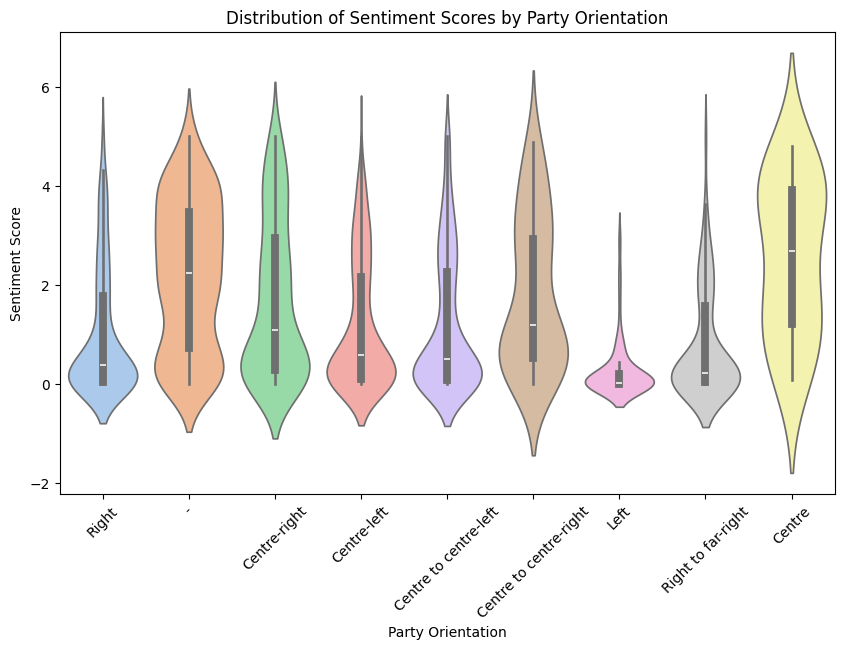

In [19]:
#Political orientation x sentiment scores (distributions)
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    x="Party_orientation", 
    y="Senti_n", 
    hue="Party_orientation", 
    palette="pastel",
)
plt.title("Distribution of Sentiment Scores by Party Orientation")
plt.xlabel("Party Orientation")
plt.ylabel("Sentiment Score")
plt.xticks(rotation=45)
plt.show()


In [20]:
#Political orientation x Sentiment scores (across years)

status_term = df.groupby(["Party_orientation", "Year"]).agg({"Senti_n":"mean"}).reset_index()
status_term

fig=px.line(status_term, x="Year", y="Senti_n", color="Party_orientation", markers=True, 
            color_discrete_sequence=px.colors.qualitative.Vivid)
fig.update_layout(
    height=500,  
    width=950,
    yaxis=dict(range=[0, 5]),

    yaxis_title='Avg. Sentiment score',
    legend_title='Orientation',
    template='plotly_white'
)
fig.show()

### Parliamentary groups/Political parties x Sentiment

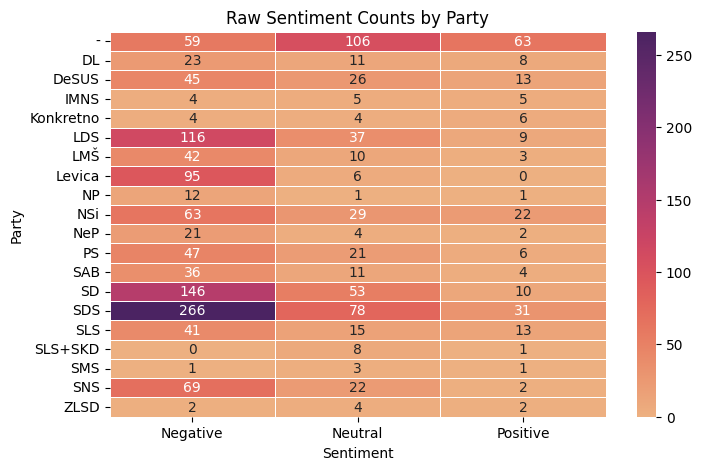

In [21]:
# Political party x Sentiment categories 
mode = ""
senti_version = 3

if senti_version == 3:
    crosstab = pd.crosstab(df['Speaker_party'], df['Senti_3'])
elif senti_version == 6:
    crosstab = pd.crosstab(df['Speaker_party'], df['Senti_6'])
else:
    raise ValueError("Senti_version must be either 3 or 6")

if mode == "row":
    # Each row sums to 100%
    data = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
    fmt = ".1f"
    title = "Sentiment Distribution (%) within each Party"

elif mode == "col":
    # Each column sums to 100%
    data = crosstab.div(crosstab.sum(axis=0), axis=1) * 100
    fmt = ".1f"
    title = "Party Contributions (%) within each Sentiment"

elif mode == "global":
    # Whole table sums to 100%
    data = crosstab / crosstab.values.sum() * 100
    fmt = ".2f"
    title = "Overall Share of Dataset (%)"

else:  # raw counts
    data = crosstab
    fmt = "g"
    title = "Raw Sentiment Counts by Party"


plt.figure(figsize=(8, 5))
sns.heatmap(data, cmap="flare", annot=True, linewidth=.5, fmt=fmt)
plt.title(title)
plt.ylabel("Party")
plt.xlabel("Sentiment")
plt.show()


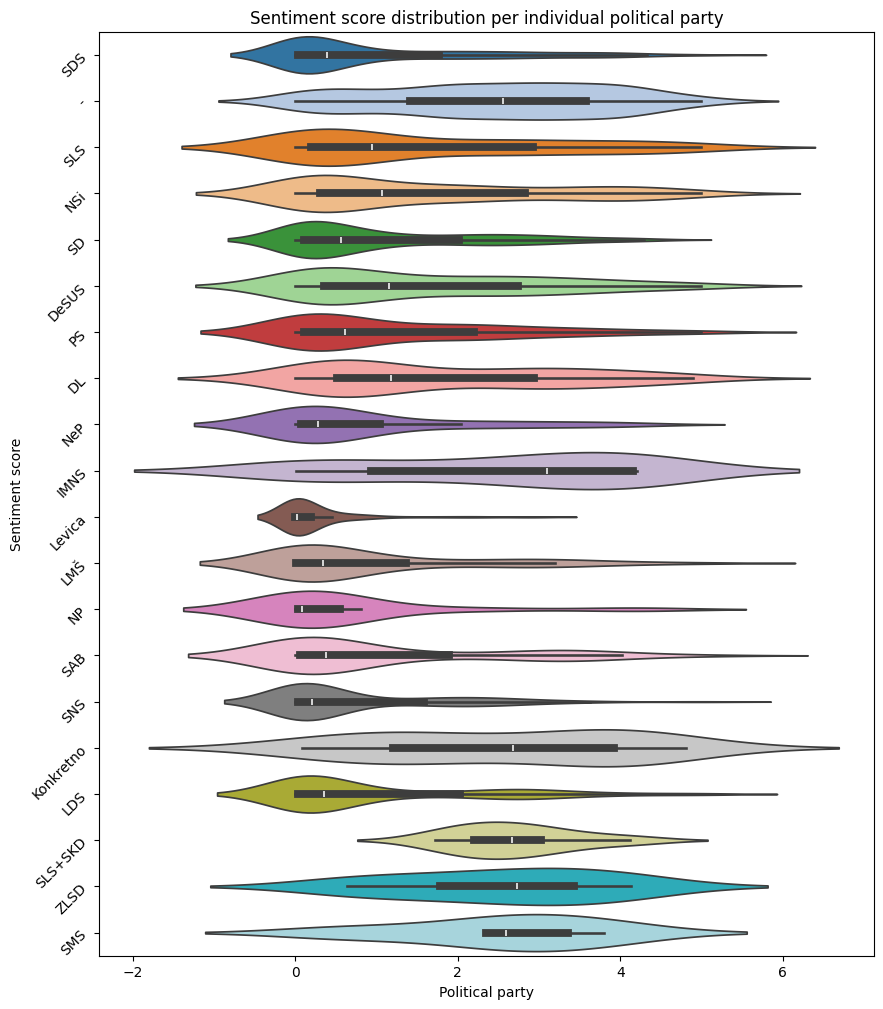

In [22]:
#Parliamentary groups x Sentiment score distributions
plt.figure(figsize=(10, 12))
sns.violinplot(
    data=df,
    x="Senti_n", 
    y="Speaker_party",
    hue="Speaker_party",
    palette="tab20"
)

plt.title("Sentiment score distribution per individual political party")
plt.xlabel("Political party"), 
plt.ylabel("Sentiment score"), 
plt.yticks(rotation=45), 
plt.show()

In [23]:
party_sent = df.groupby(["Term", "Year", "Speaker_party"])["Senti_n"].mean().reset_index()
party_sent = party_sent.sort_values(by="Term")
party_sent["Senti_n"] = pd.to_numeric(party_sent["Senti_n"])
party_sent.head(10)


,Term,Year,Speaker_party,Senti_n
0,Term 3,2000,-,3.765000
1,Term 3,2000,DeSUS,3.203333
2,Term 3,2000,IMNS,2.470000
3,Term 3,2000,LDS,2.901000
4,Term 3,2000,NSi,1.613333
5,Term 3,2000,SDS,2.740000
6,Term 3,2000,SLS+SKD,2.702222
7,Term 3,2000,SMS,2.552000
8,Term 3,2000,SNS,1.899500
9,Term 3,2000,ZLSD,2.557500


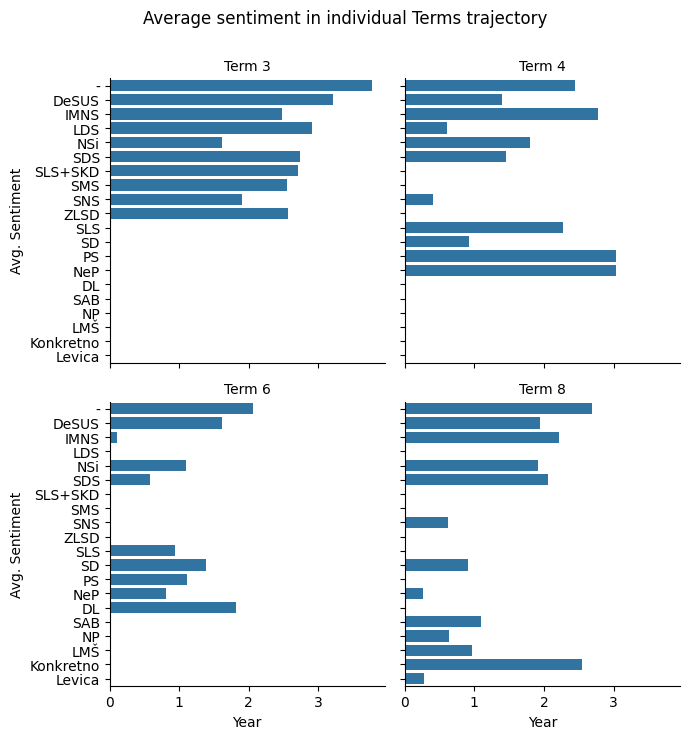

In [24]:
g = sns.FacetGrid(party_sent, col="Term" , col_wrap=2, height=3.5) 
g.map_dataframe(sns.barplot, x="Senti_n", y="Speaker_party") 
g.set_axis_labels("Year", "Avg. Sentiment") 
g.set_titles("{col_name}"),
g.legend
g.figure.suptitle("Average sentiment in individual Terms trajectory", y=1.05)
plt.show()

## Families x Sentiment 

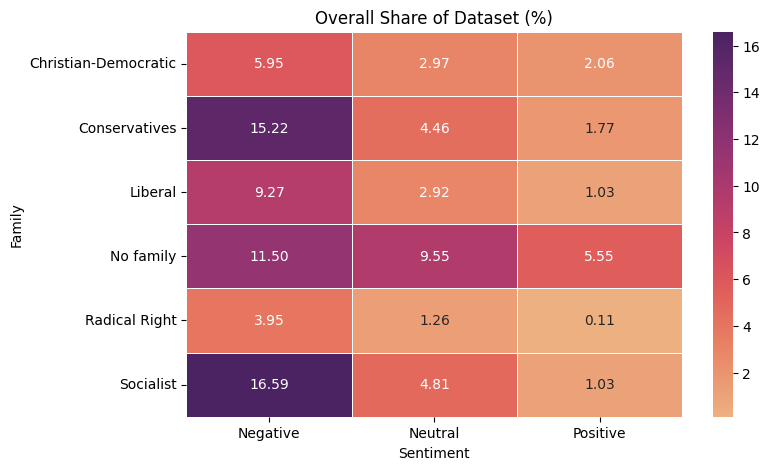

In [25]:
# Political party x Sentiment categories 
mode = "global"
senti_version = 3

if senti_version == 3:
    crosstab = pd.crosstab(df['Family'], df['Senti_3'])
elif senti_version == 6:
    crosstab = pd.crosstab(df['Family'], df['Senti_6'])
else:
    raise ValueError("Senti_version must be either 3 or 6")

if mode == "row":
    # Each row sums to 100%
    data = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
    fmt = ".1f"
    title = "Sentiment Distribution (%) within each Family"

elif mode == "col":
    # Each column sums to 100%
    data = crosstab.div(crosstab.sum(axis=0), axis=1) * 100
    fmt = ".1f"
    title = "Family Contributions (%) within each Sentiment"

elif mode == "global":
    # Whole table sums to 100%
    data = crosstab / crosstab.values.sum() * 100
    fmt = ".2f"
    title = "Overall Share of Dataset (%)"

else:  # raw counts
    data = crosstab
    fmt = "g"
    title = "Raw Sentiment Counts by Family"


plt.figure(figsize=(8, 5))
sns.heatmap(data, cmap="flare", annot=True, linewidth=.5, fmt=fmt)
plt.title(title)
plt.ylabel("Family")
plt.xlabel("Sentiment")
plt.show()

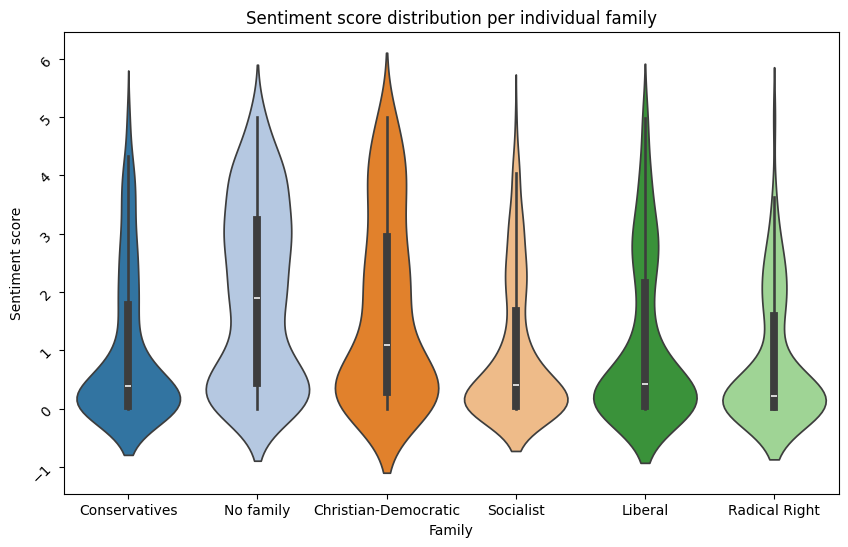

In [26]:
#Family x Sentiment score distributions
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    x="Family", 
    y="Senti_n",
    hue="Family",
    palette="tab20"
)

plt.title("Sentiment score distribution per individual family")
plt.xlabel("Family"), 
plt.ylabel("Sentiment score"), 
plt.yticks(rotation=45), 
plt.show()